In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
import warnings
warnings.filterwarnings('ignore')

# Load the California House Pricing Dataset

In [3]:
from sklearn.datasets import fetch_california_housing

In [4]:
house=fetch_california_housing()

In [5]:
type(house)

sklearn.utils._bunch.Bunch

# Bunch 
- Bunch is a custom class created by Scikit-learn.
- A Bunch object is a dictionary-like container used by Scikit-learn to store dataset components such as features, target values, feature names, and dataset description.
- which stores different parts of the dataset like data, target, feature_names, and DESCR as attributes.

In [6]:
house.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [7]:
# Lets check the description of the dataset
print(house.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [8]:
print(house.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [9]:
print(house.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [10]:
print(house.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Preparing the Dataset

In [11]:
data=pd.DataFrame(house.data,columns=house.feature_names)
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [12]:
data['Price']=house.target

In [13]:
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


# Summarizing the stats of the data

In [15]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# Check the missing values

In [16]:
data.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

# Exploratory Data Analysis
- Correlation - important one because we need to find out how my independent features and my output features are correlated.

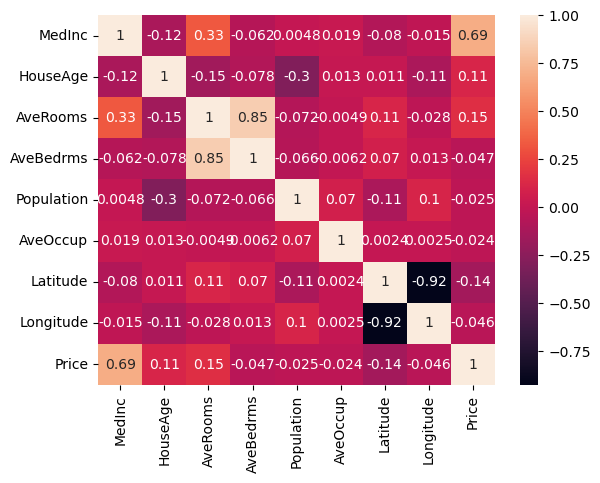

In [17]:
 sns.heatmap(data=data.corr(),annot=True)
plt.show()

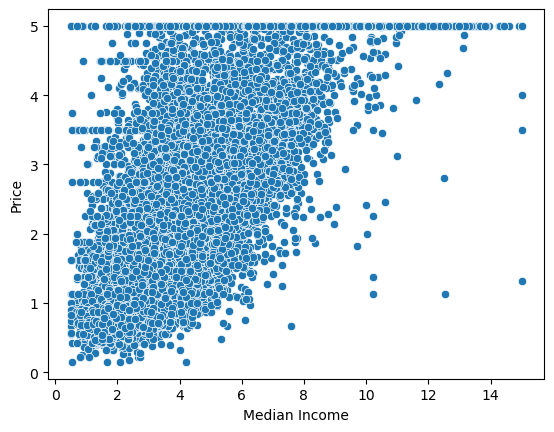

In [18]:
sns.scatterplot(x=data['MedInc'],y=data['Price'])
plt.xlabel('Median Income')
plt.ylabel('Price')
plt.show()

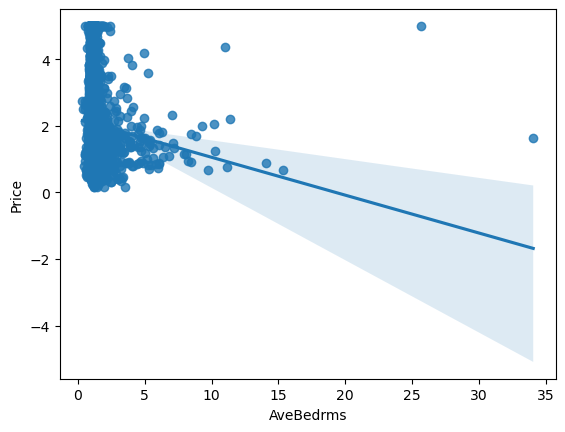

In [19]:
sns.regplot(x=data['AveBedrms'],y=data['Price'])
plt.show()

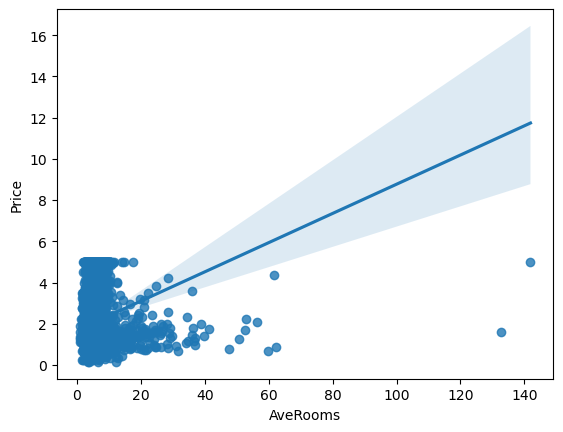

In [20]:
sns.regplot(x=data['AveRooms'],y=data['Price'])
plt.show()

<Figure size 2000x2000 with 0 Axes>

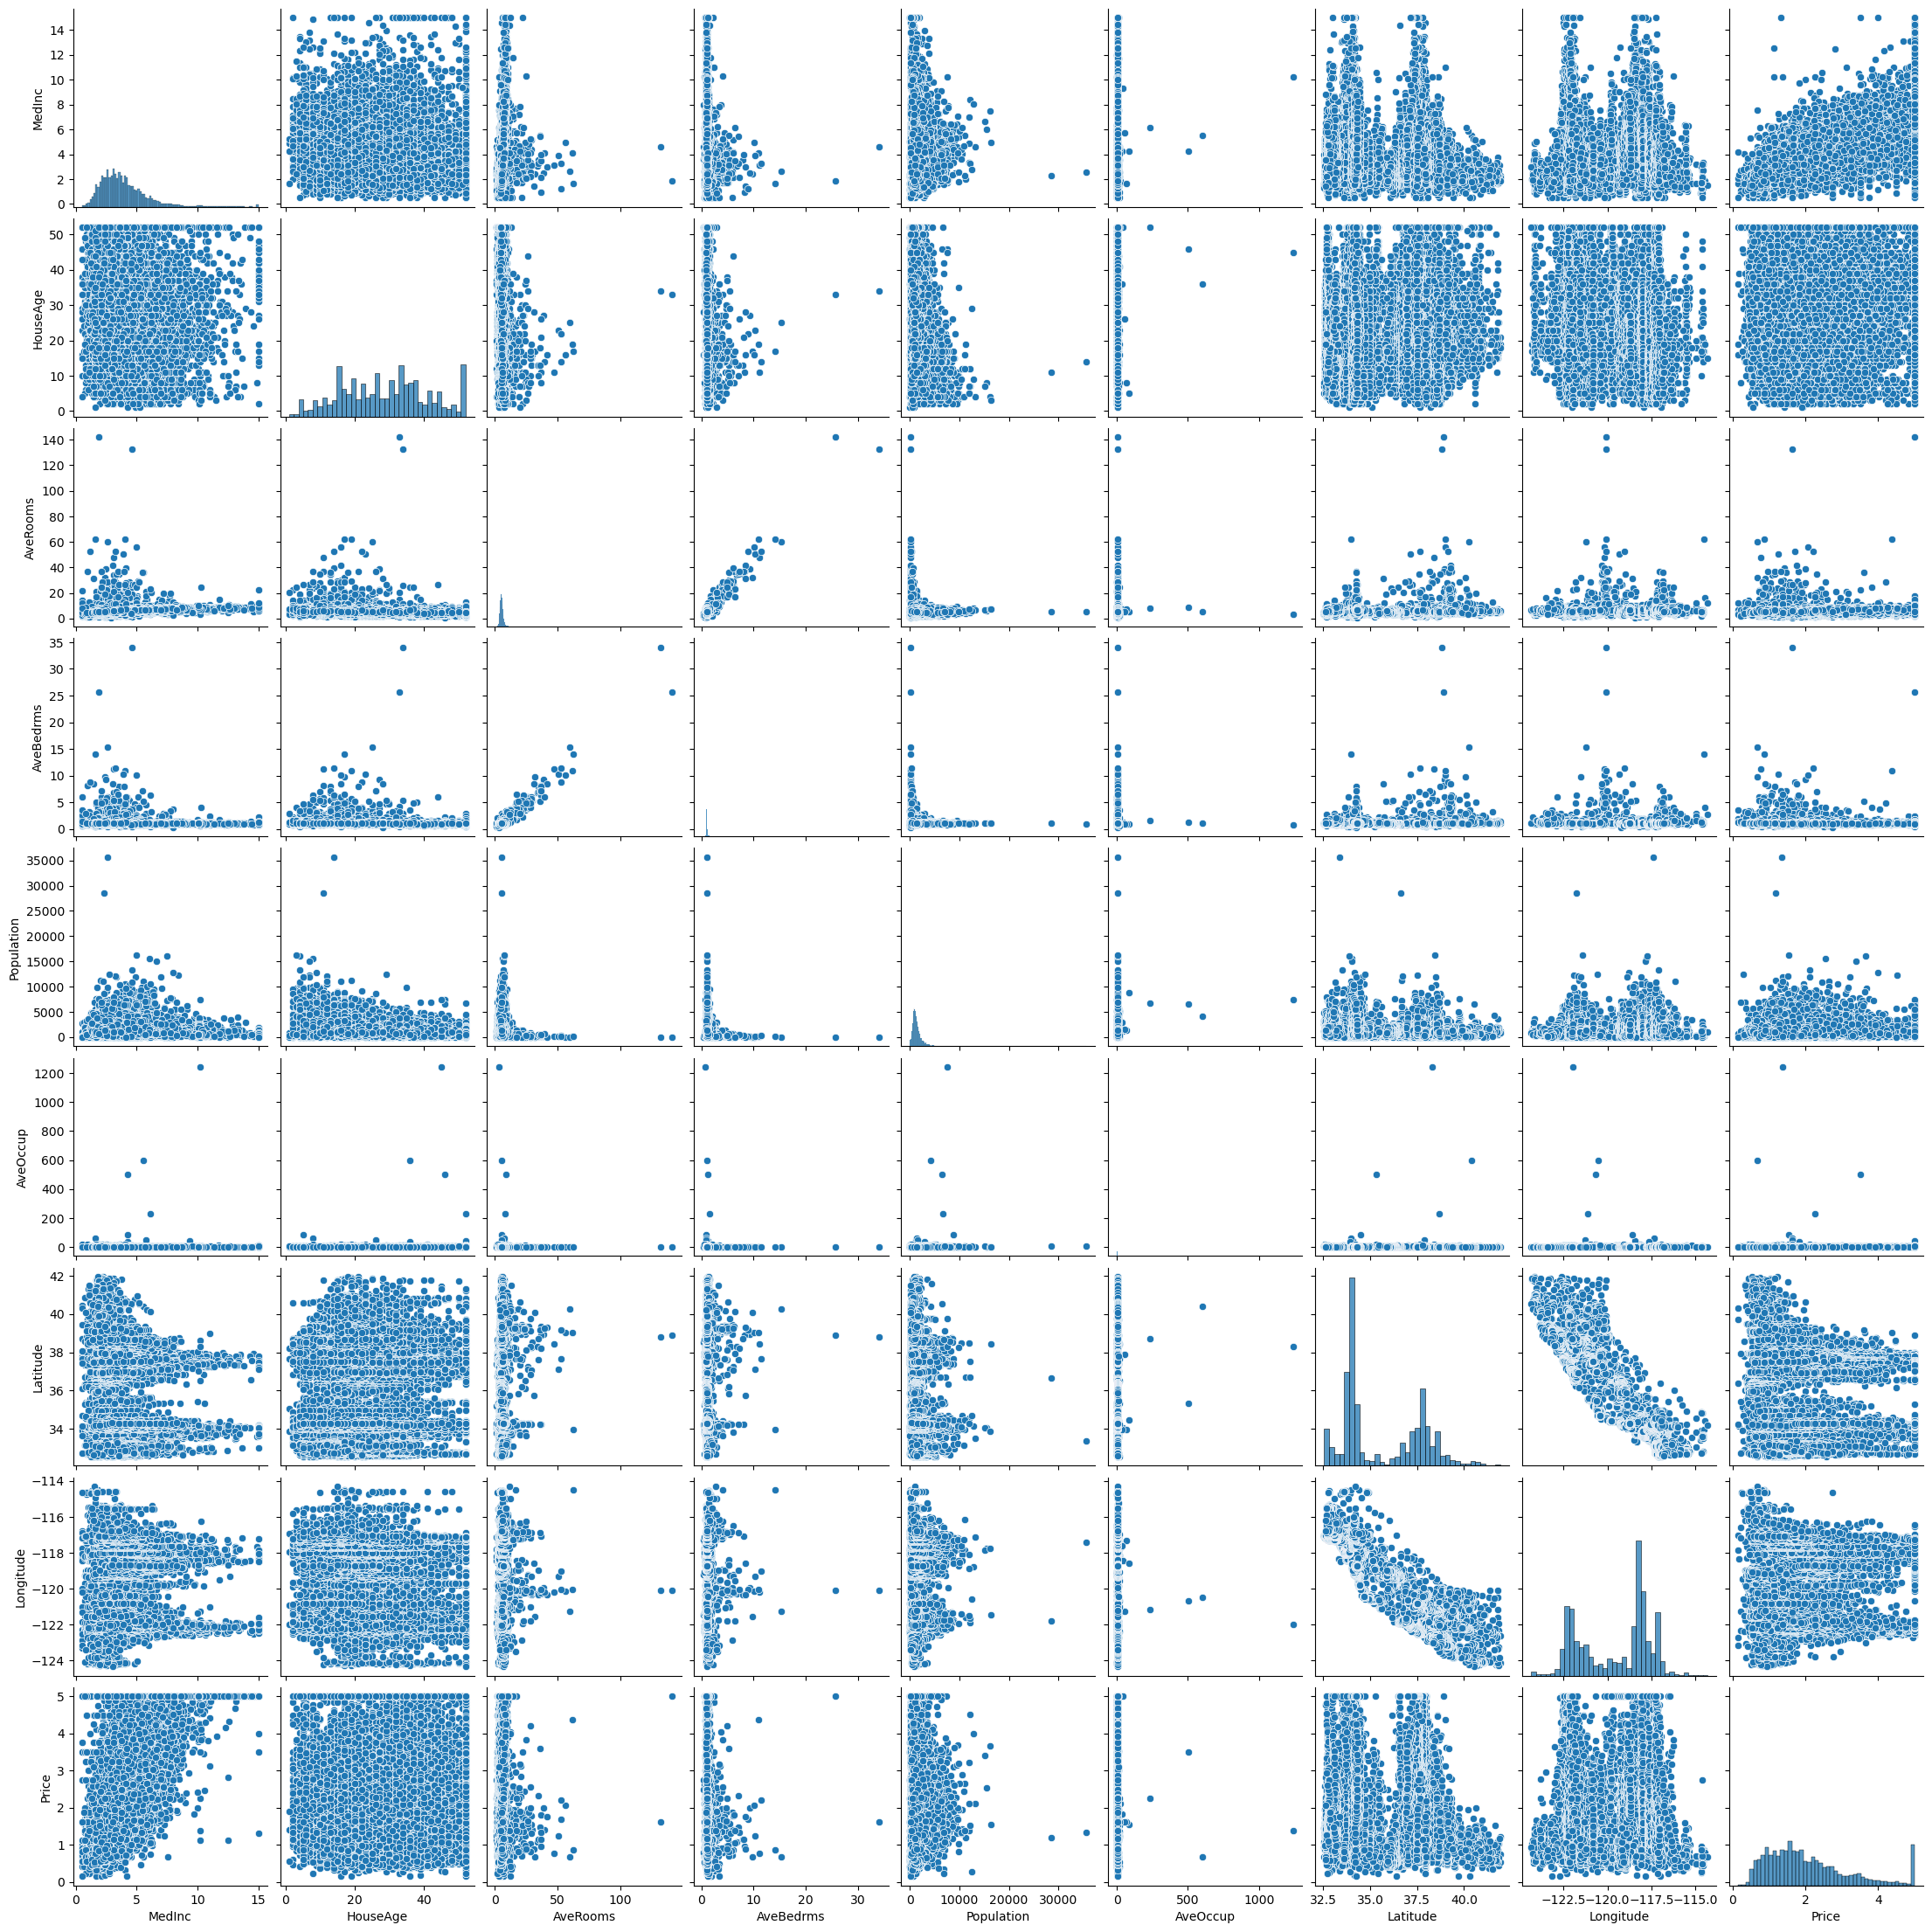

In [21]:
plt.figure(figsize=(20,20))
sns.pairplot(data=data)
plt.show()

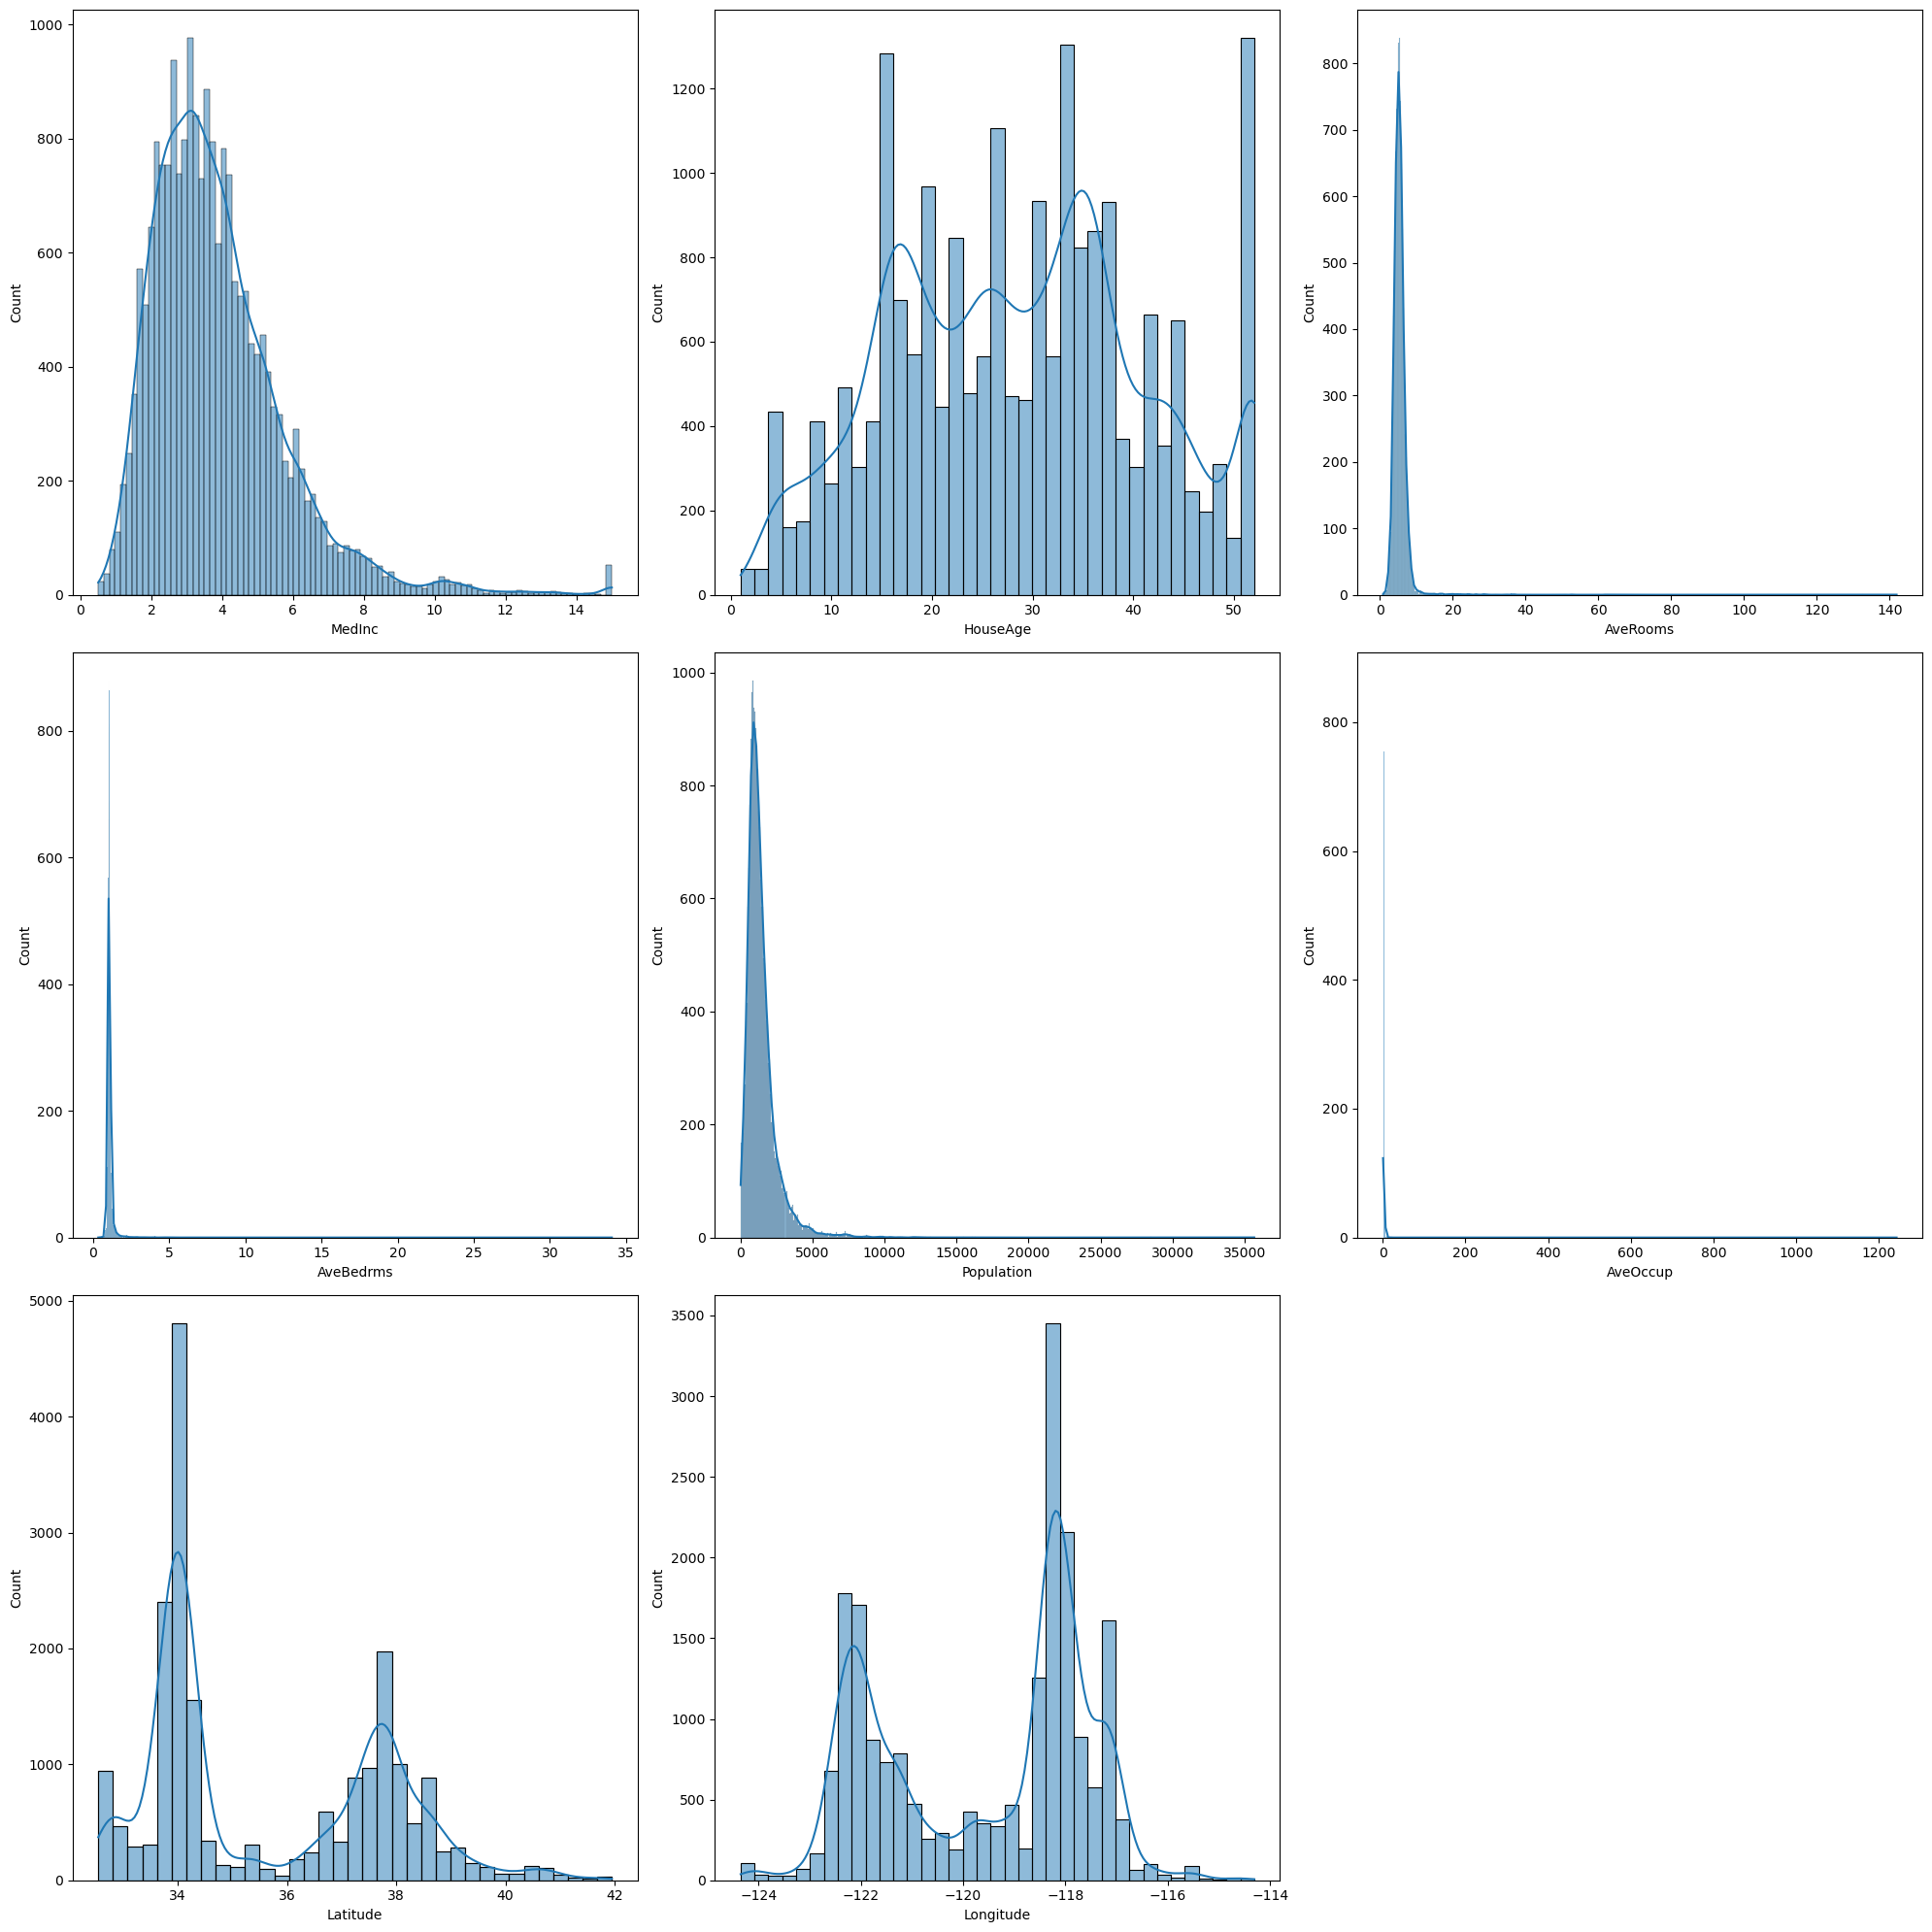

In [22]:
plt.figure(figsize=(20,20))
plot=1
for i in data:
    if plot<=8:
        ax=plt.subplot(3,3,plot)
        sns.histplot(data[i],kde=True)
        plt.xlabel(i)
        plt.ylabel('Count')
    plot+=1
plt.tight_layout()
plt.show()

## Handle a skewness column

In [23]:
def skewness():
    for col in data:
        print(col,'-',data[col].skew())
skewness()  

MedInc - 1.6466567021344465
HouseAge - 0.060330637599136865
AveRooms - 20.697868956710646
AveBedrms - 31.316956246782663
Population - 4.93585822672712
AveOccup - 97.63956096369479
Latitude - 0.46595300370997006
Longitude - -0.2978012079524362
Price - 0.9777632739098345


In [24]:
def transform():
    for col in ['MedInc','AveRooms','AveBedrms','Population','AveOccup']:
        data[col]=np.log1p(data[col])
transform()

In [25]:
def skewness():
    for col in data:
        print(col,'-',data[col].skew())
skewness()

MedInc - 0.22608313067130548
HouseAge - 0.060330637599136865
AveRooms - 1.3907612222121986
AveBedrms - 8.988786093389573
Population - -1.0440866961519721
AveOccup - 3.8796788829093227
Latitude - 0.46595300370997006
Longitude - -0.2978012079524362
Price - 0.9777632739098345


In [26]:
data['AveRooms']=np.log1p(data['AveRooms'])
data['AveBedrms']=np.log1p(data['AveBedrms'])
data['Population']=np.log1p(data['Population'])
data['AveOccup']=np.log1p(data['AveOccup'])

In [27]:
def skewness():
    for col in data:
        print(col,'-',data[col].skew())
skewness()

MedInc - 0.22608313067130548
HouseAge - 0.060330637599136865
AveRooms - 0.3350999201406715
AveBedrms - 6.436582314806414
Population - -2.126126548657117
AveOccup - 0.9601537187001853
Latitude - 0.46595300370997006
Longitude - -0.2978012079524362
Price - 0.9777632739098345


In [28]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer()
data['AveBedrms']=pt.fit_transform(data[['AveBedrms']])

In [29]:
data['Population']=pt.fit_transform(data[['Population']])

In [30]:
def skewness():
    for col in data:
        print(col,'-',data[col].skew())
skewness()

MedInc - 0.22608313067130548
HouseAge - 0.060330637599136865
AveRooms - 0.3350999201406715
AveBedrms - -1.765579118168257
Population - 0.14291439211139487
AveOccup - 0.9601537187001853
Latitude - 0.46595300370997006
Longitude - -0.2978012079524362
Price - 0.9777632739098345


In [31]:
data['AveBedrms']=pt.fit_transform(data[['AveBedrms']])

In [32]:
data['AveBedrms'].skew()

np.float64(-1.2785095940456763)

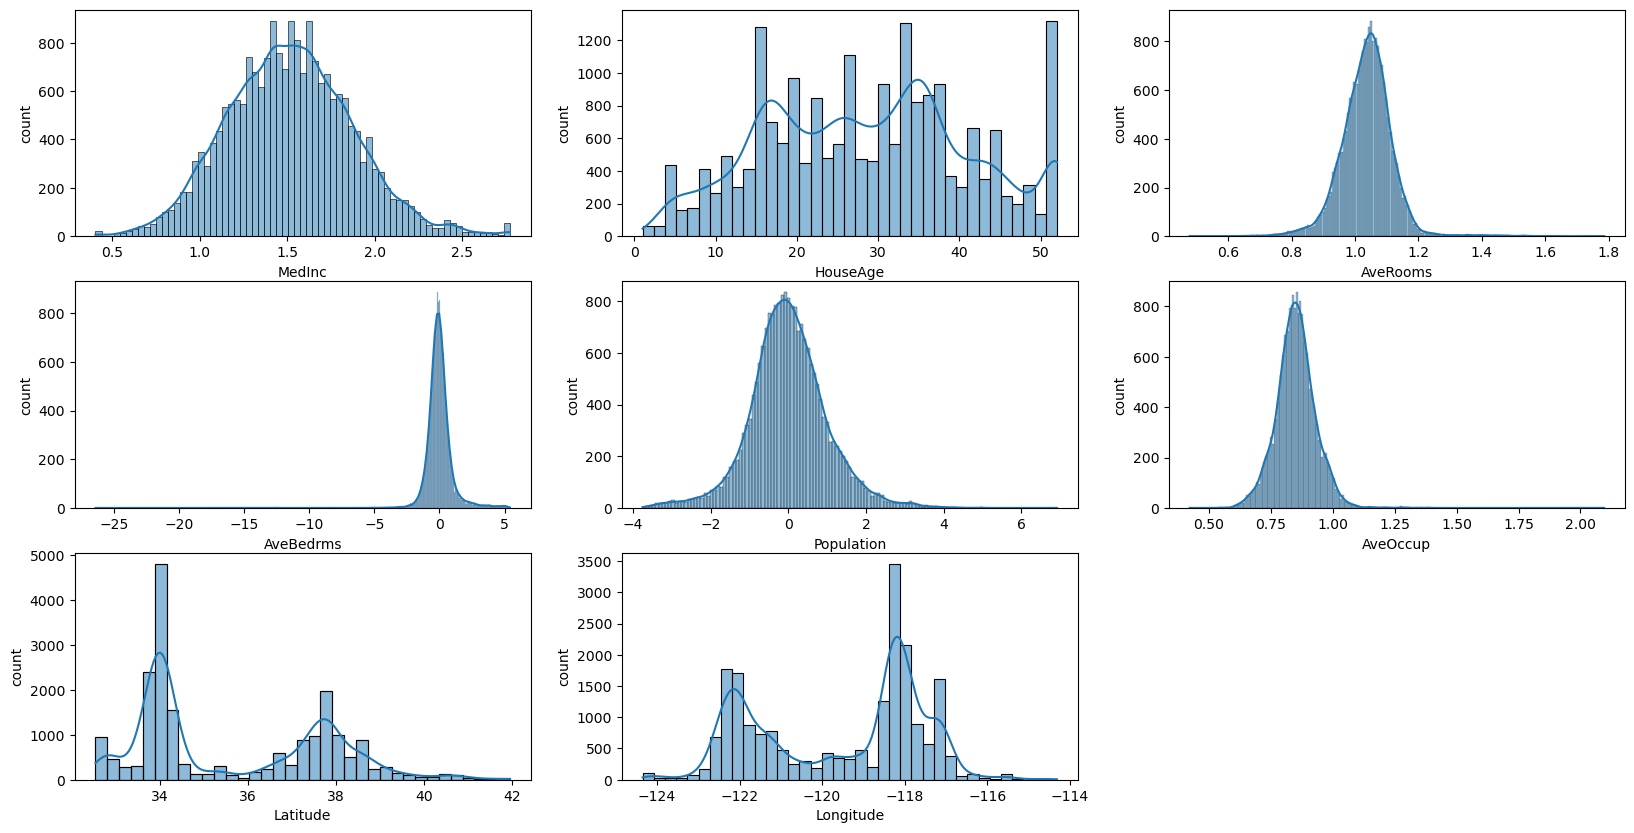

In [33]:
plt.figure(figsize=(20,10))
plot=1
for col in data:
    if plot<=8:
        ax=plt.subplot(3,3,plot)
        sns.histplot(data[col],kde=True)
        plt.xlabel(col)
        plt.ylabel('count')
    plot+=1
plt.show()

## Handles a Outliers

In [34]:
col1=data.columns
col1

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

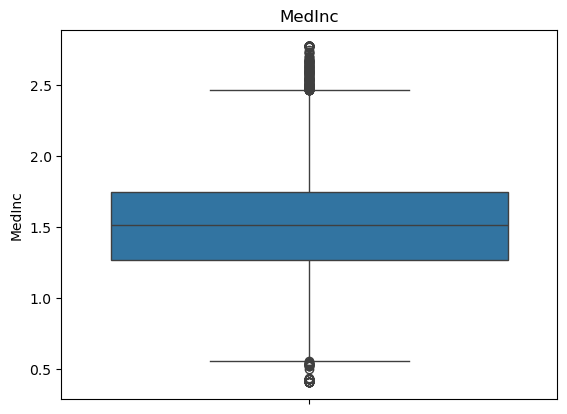

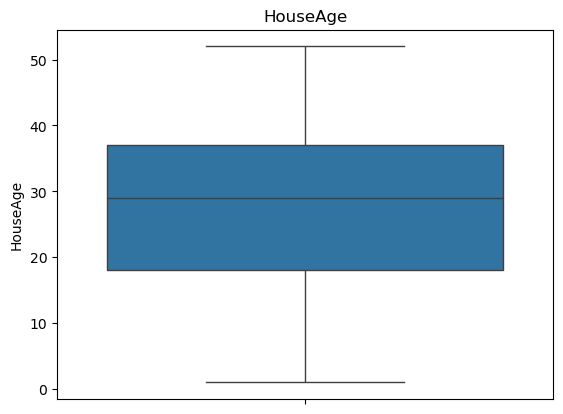

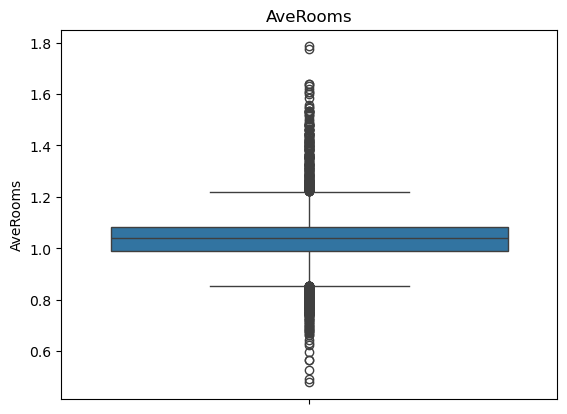

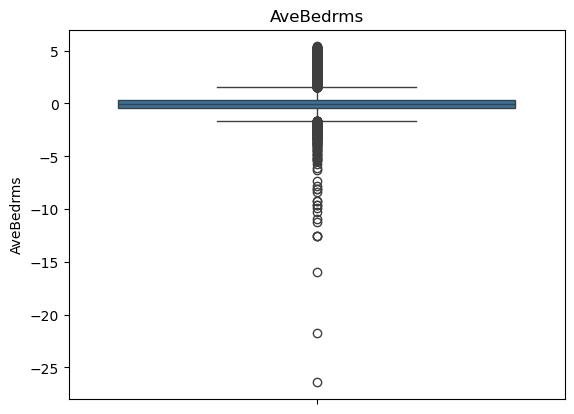

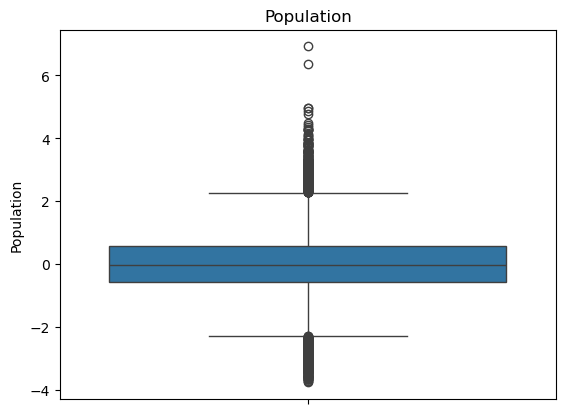

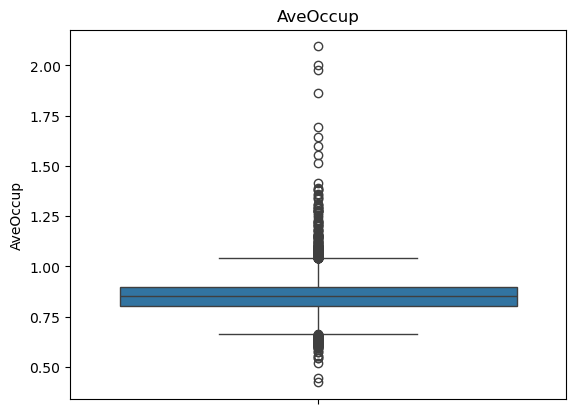

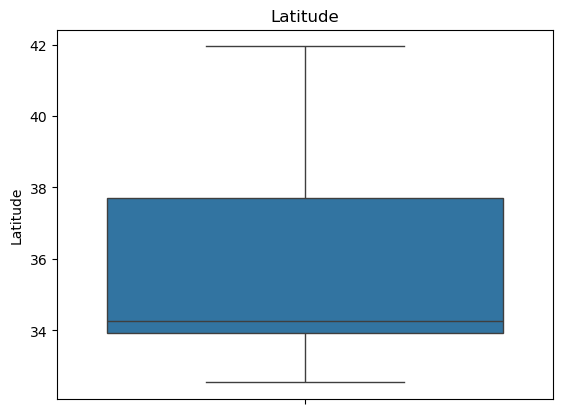

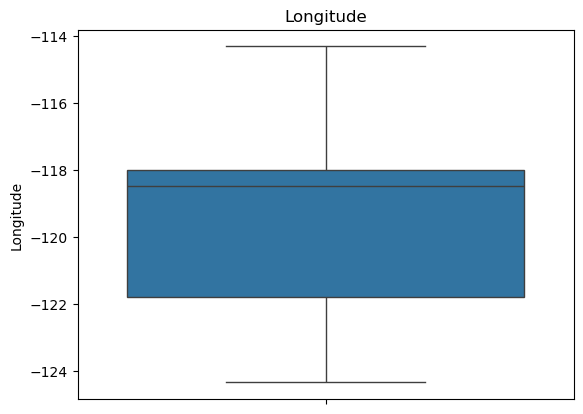

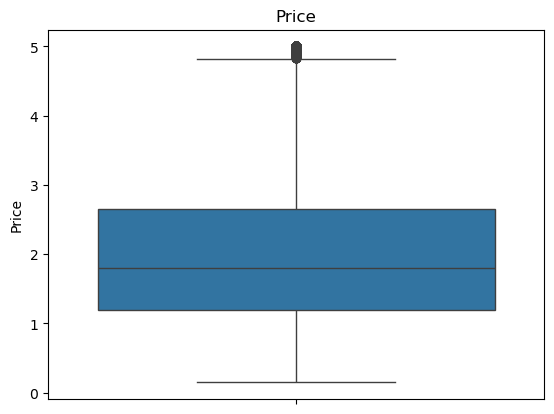

In [35]:
for col in col1:
    sns.boxplot(data[col])
    plt.title(col)
    plt.show()

In [36]:
def check_outliers(data):
    for col in data.columns:
        Q1=data[col].quantile(0.25)
        Q3=data[col].quantile(0.75)
        IQR=Q3-Q1
        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        outliers=data[(data[col]<lower)|(data[col]>upper)]
        print(col,':',len(outliers),'outliers')
check_outliers(data)

MedInc : 226 outliers
HouseAge : 0 outliers
AveRooms : 585 outliers
AveBedrms : 1315 outliers
Population : 793 outliers
AveOccup : 480 outliers
Latitude : 0 outliers
Longitude : 0 outliers
Price : 1071 outliers


In [37]:
def cap_outliers(data):
    for col in data.columns:
        Q1=data[col].quantile(0.25)
        Q3=data[col].quantile(0.75)
        IQR=Q3-Q1
        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        data[col]=np.clip(data[col],lower,upper)
cap_outliers(data)

In [38]:
def check_outliers(data):
    for col in data.columns:
        Q1=data[col].quantile(0.25)
        Q3=data[col].quantile(0.75)
        IQR=Q3-Q1
        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        outliers=data[(data[col]<lower)|(data[col]>upper)]
        print(col,':',len(outliers),'outliers')
check_outliers(data)

MedInc : 0 outliers
HouseAge : 0 outliers
AveRooms : 0 outliers
AveBedrms : 0 outliers
Population : 0 outliers
AveOccup : 0 outliers
Latitude : 0 outliers
Longitude : 0 outliers
Price : 0 outliers


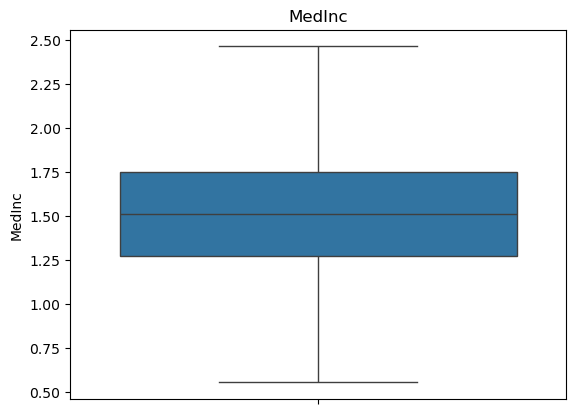

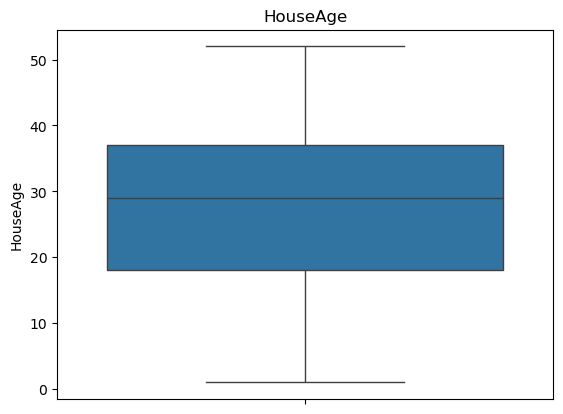

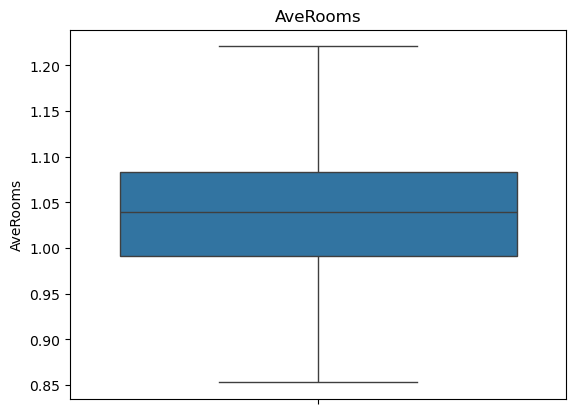

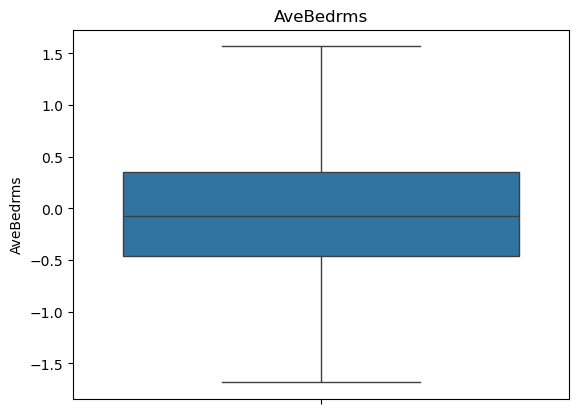

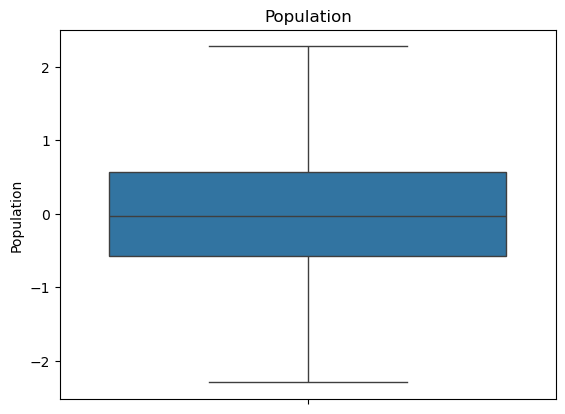

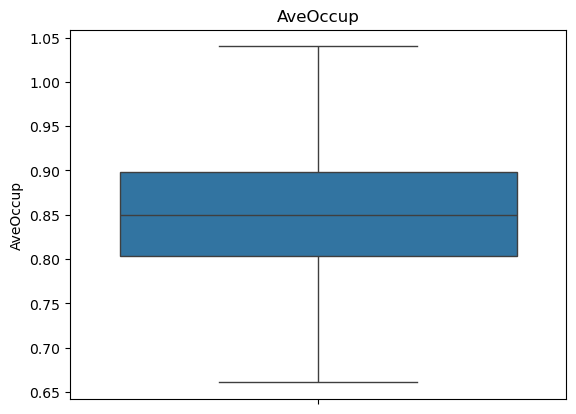

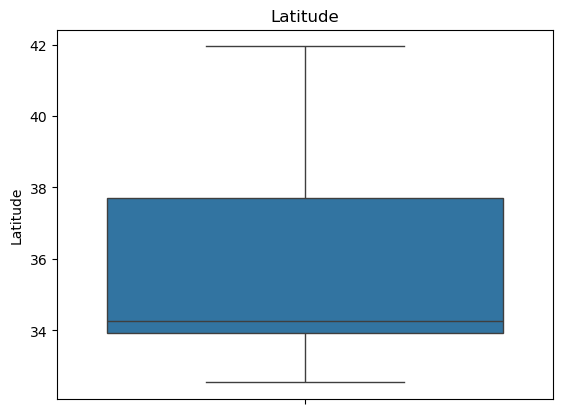

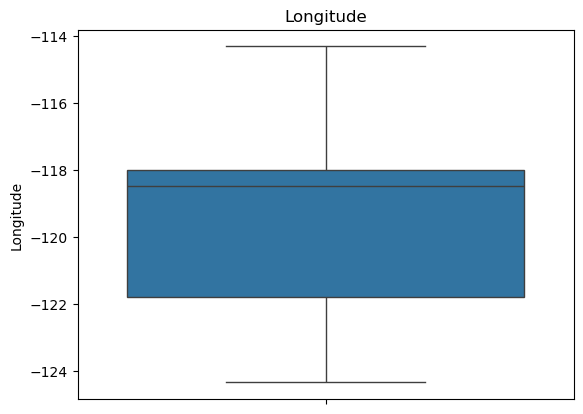

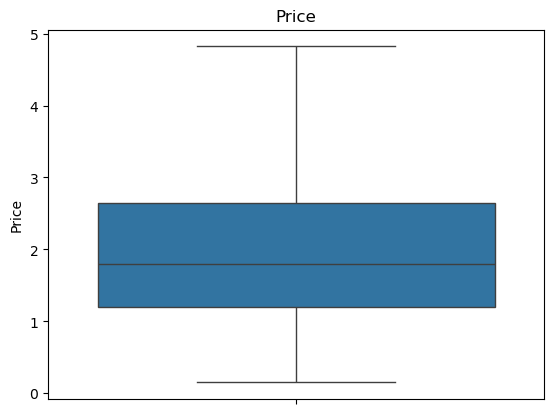

In [39]:
for col in col1:
    sns.boxplot(data[col])
    plt.title(col)
    plt.show()

# Correlation

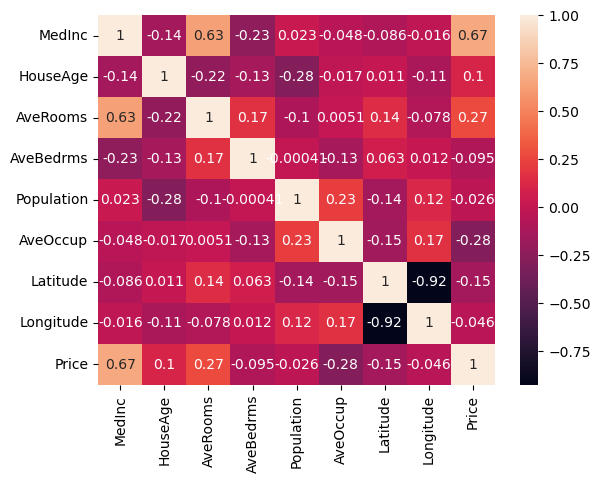

In [40]:
sns.heatmap(data.corr(),annot=True)
plt.show()

In [41]:
cor=data.corr()
cor

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.141765,0.628562,-0.229657,0.023170,-0.048159,-0.085999,-0.015630,0.669951
HouseAge,-0.141765,1.000000,-0.220803,-0.133062,-0.281047,-0.017088,0.011173,-0.108197,0.104423
AveRooms,0.628562,-0.220803,1.000000,0.171195,-0.101850,0.005144,0.144123,-0.078486,0.274181
AveBedrms,-0.229657,-0.133062,0.171195,1.000000,-0.000413,-0.131320,0.062731,0.011686,-0.094693
Population,0.023170,-0.281047,-0.101850,-0.000413,1.000000,0.225260,-0.142432,0.119048,-0.026071
AveOccup,-0.048159,-0.017088,0.005144,-0.131320,0.225260,1.000000,-0.152106,0.165653,-0.280322
Latitude,-0.085999,0.011173,0.144123,0.062731,-0.142432,-0.152106,1.000000,-0.924664,-0.145494
Longitude,-0.015630,-0.108197,-0.078486,0.011686,0.119048,0.165653,-0.924664,1.000000,-0.046311
Price,0.669951,0.104423,0.274181,-0.094693,-0.026071,-0.280322,-0.145494,-0.046311,1.000000


In [42]:
cor[cor>0.8]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HouseAge,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AveRooms,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
AveBedrms,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
Population,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
AveOccup,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
Latitude,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
Longitude,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
Price,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [43]:
# Splitting a independent and dependent columns
x=data[data.columns[:-1]]
y=data['Price']

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=pd.DataFrame({
    'Features':x.columns,
    'VIF':[variance_inflation_factor(x.values,i)
           for i in range(x.shape[1])]
           })
print(vif.sort_values('VIF',ascending=False))

     Features          VIF
7   Longitude  1103.621245
6    Latitude   584.523710
2    AveRooms   466.656980
5    AveOccup   142.196069
0      MedInc    44.073788
1    HouseAge     7.450790
3   AveBedrms     1.365048
4  Population     1.223296


In [45]:
x=x.drop(['Longitude'],axis=1)

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=pd.DataFrame({
    'Features':x.columns,
    'VIF':[variance_inflation_factor(x.values,i)
           for i in range(x.shape[1])]
           })
print(vif.sort_values('VIF',ascending=False))

     Features         VIF
2    AveRooms  407.375562
6    Latitude  199.939957
5    AveOccup  113.490830
0      MedInc   44.069396
1    HouseAge    6.954020
3   AveBedrms    1.359319
4  Population    1.207209


In [47]:
x['Bedroom_ratio']=x['AveBedrms']/x['AveRooms']

In [48]:
x=x.drop(['AveBedrms','AveRooms'],axis=1)

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=pd.DataFrame({
    'Features':x.columns,
    'VIF':[variance_inflation_factor(x.values,i)
           for i in range(x.shape[1])]
           })
print(vif.sort_values('VIF',ascending=False))

        Features        VIF
4       Latitude  94.635695
3       AveOccup  85.709794
0         MedInc  19.054546
1       HouseAge   6.879145
2     Population   1.161798
5  Bedroom_ratio   1.095592


In [50]:
x=x.drop(['AveOccup'],axis=1)

In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=pd.DataFrame({
    'Features':x.columns,
    'VIF':[variance_inflation_factor(x.values,i)
           for i in range(x.shape[1])]
           })
print(vif.sort_values('VIF',ascending=False))

        Features        VIF
3       Latitude  26.373755
0         MedInc  18.676595
1       HouseAge   6.744683
4  Bedroom_ratio   1.086284
2     Population   1.073940


In [52]:
x

,MedInc,HouseAge,Population,Latitude,Bedroom_ratio
0,2.232720,41.0,-1.641977,37.88,-0.263733
1,2.230165,21.0,1.104677,37.86,-0.744361
2,2.111110,52.0,-1.160646,37.85,0.118350
3,1.893579,52.0,-1.019268,37.85,0.126487
4,1.578195,52.0,-1.004047,37.85,0.183972
...,...,...,...,...,...
20635,0.940124,25.0,-0.485915,39.48,0.583098
20636,1.268861,18.0,-1.535315,39.49,1.442879
20637,0.993252,17.0,-0.243799,39.43,0.484908
20638,1.053336,18.0,-0.660693,39.43,0.827711


# Train Test Split

In [53]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [54]:
x_train

,MedInc,HouseAge,Population,Latitude,Bedroom_ratio
8158,1.651405,37.0,-0.462076,33.81,-0.762126
18368,1.847951,42.0,-0.315130,37.16,0.233632
19197,1.593126,36.0,-0.714542,38.45,0.021850
3746,1.997458,32.0,-0.042506,34.16,-0.576367
13073,1.214438,17.0,-0.723682,38.57,-0.186568
...,...,...,...,...,...
11284,1.997418,35.0,-0.814003,33.78,-1.221788
11964,1.398717,33.0,0.587637,34.02,1.289019
5390,1.369758,36.0,0.590359,34.03,0.198268
860,1.904969,15.0,0.609307,37.58,0.084867


In [56]:
x_test

,MedInc,HouseAge,Population,Latitude,Bedroom_ratio
20046,0.986264,25.0,0.229505,36.06,-0.319144
3024,1.261666,30.0,0.409247,35.14,0.975713
15663,1.499645,52.0,0.138128,37.80,0.998433
20484,1.907704,17.0,0.543584,34.28,-0.303407
9814,1.552868,34.0,-0.167072,36.62,-0.244018
...,...,...,...,...,...
5363,2.031563,51.0,-0.608464,34.04,-0.739927
19755,1.159958,30.0,-1.379967,40.18,-1.108104
4885,1.152690,37.0,0.937097,34.02,-0.000143
13043,2.065203,6.0,1.071209,38.51,-0.209349


In [55]:
y_train

8158     2.285
18368    2.799
19197    1.830
3746     4.658
13073    1.500
         ...  
11284    2.292
11964    0.978
5390     2.221
860      2.835
15795    3.250
Name: Price, Length: 15480, dtype: float64

# Standardize the dataset

In [58]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)

In [63]:
x_train=pd.DataFrame(x_train,columns=x.columns)
x_train

,MedInc,HouseAge,Population,Latitude,Bedroom_ratio
0,0.378898,0.666407,-0.494176,-0.860741,-1.074762
1,0.933765,1.062889,-0.337078,0.709168,0.404914
2,0.214370,0.587111,-0.764083,1.313701,0.090210
3,1.355839,0.269925,-0.045620,-0.696721,-0.798728
4,-0.854700,-0.919520,-0.773855,1.369936,-0.219495
...,...,...,...,...,...
15475,1.355724,0.507814,-0.870415,-0.874800,-1.757811
15476,-0.334464,0.349222,0.628055,-0.762329,1.973197
15477,-0.416216,0.587111,0.630965,-0.757643,0.352363
15478,1.094733,-1.078113,0.651222,0.905993,0.183852


In [65]:
x_test=pd.DataFrame(x_test,columns=x.columns)
x_test

,MedInc,HouseAge,Population,Latitude,Bedroom_ratio
0,-1.498855,-0.285149,0.245182,0.193675,-0.416500
1,-0.721371,0.111332,0.437341,-0.237464,1.507630
2,-0.049533,1.855852,0.147492,1.009091,1.541393
3,1.102453,-0.919520,0.580959,-0.640486,-0.393116
4,0.100718,0.428518,-0.178792,0.456108,-0.304864
...,...,...,...,...,...
5155,1.452120,1.776556,-0.650677,-0.752957,-1.041776
5156,-1.008501,0.111332,-1.475478,2.124430,-1.588879
5157,-1.029020,0.666407,1.001658,-0.762329,0.057529
5158,1.547088,-1.791780,1.145034,1.341818,-0.253348


# Model Training

In [66]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(x_train,y_train)

LinearRegression()

In [67]:
# Print the coefficients and the intercept
print(regression.coef_)

[ 0.81398876  0.25101684  0.00767925 -0.10285362  0.1260876 ]


In [68]:
print(regression.intercept_)

2.0614601967054256


In [70]:
# on which parameters the model has been trained
regression.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [69]:
# Prediction with Test Data
reg_pred=regression.predict(x_test) 
reg_pred

array([0.69927929, 1.72009498, 2.57868534, ..., 1.4844829 , 2.70984387,
       3.48222664])

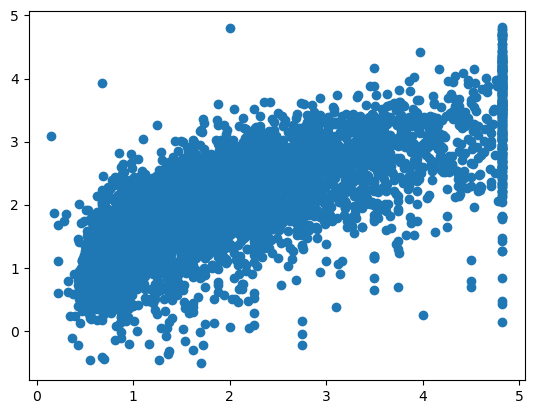

In [71]:
## Plot a Scatter plot for prediction
plt.scatter(y_test,reg_pred)
plt.show()

In [72]:
# Residuals
residuals=y_test-reg_pred
print(residuals)

20046   -0.222279
3024    -1.262095
15663    2.245440
20484   -0.562800
9814     0.615716
           ...   
5363     1.193617
19755   -0.206324
4885    -0.307483
13043   -0.078844
8583     1.332773
Name: Price, Length: 5160, dtype: float64


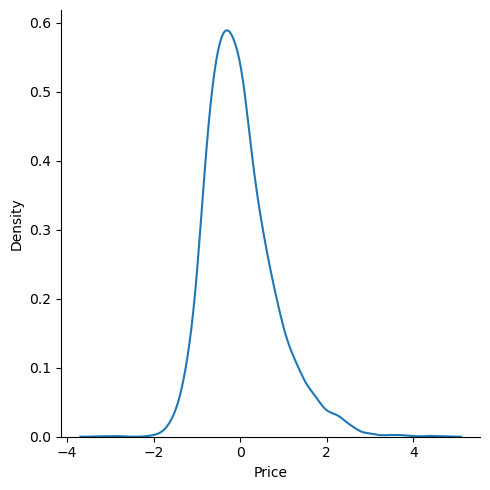

In [73]:
# Plot this residuals
sns.displot(residuals,kind='kde')
plt.show()

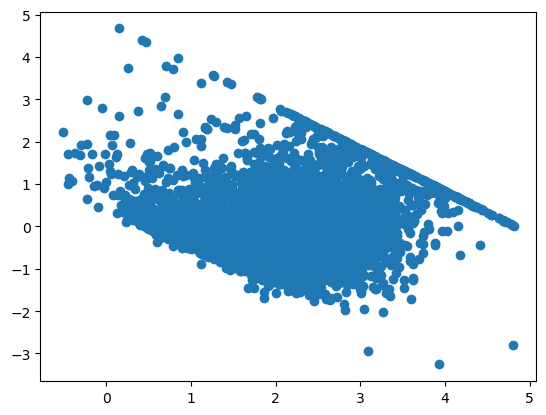

In [74]:
# SCatter plot with respect to prediction and residuals
plt.scatter(reg_pred,residuals)
plt.show()

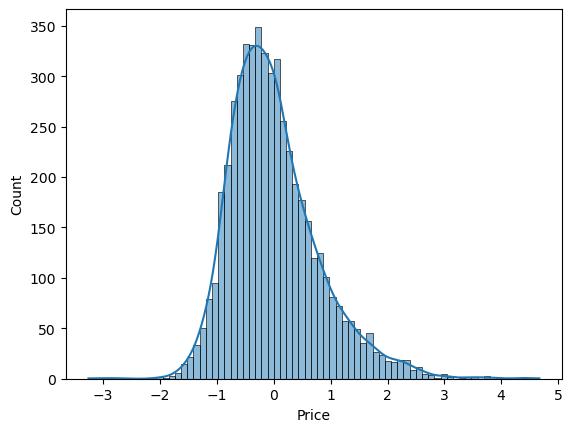

In [75]:
sns.histplot(residuals, kde=True)
plt.show()

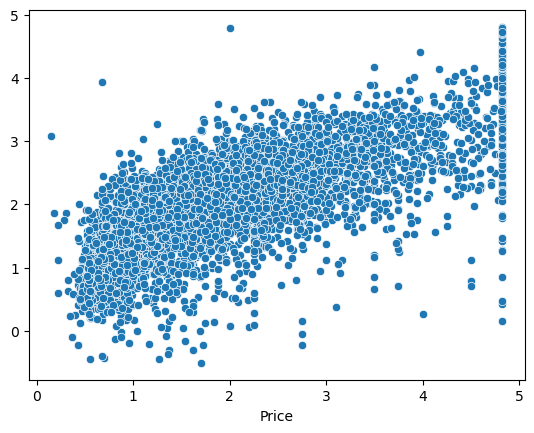

In [194]:
sns.scatterplot(x=y_test,y=reg_pred)
plt.show()

In [76]:
from sklearn.metrics import *
mse=mean_squared_error(y_test,reg_pred)
mse

0.625567129200662

In [77]:
mae=mean_absolute_error(y_test,reg_pred)
mae

0.6026307465070536

In [78]:
rmse=np.sqrt(mean_squared_error(y_test,reg_pred))
rmse

np.float64(0.7909280177112593)

# R square and adjusted R square
Formula for R square:
R^2=1-SSR/SST
- SSR=sum of square of residuals
- SST=total sum of square 

In [79]:
#from sklearn.metrics import r2_score
score=r2_score(y_test,reg_pred)
score

0.5096569401668996

Formula for adjusted R square: 1-[(1-R^2)*(n-1)/(n-k-1)]
- n=The number of observations
- k=The number of predictor variables


In [80]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.509181248413084

# Model using Ridge and Lasso

In [81]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1)
ridge.fit(x_train,y_train)
rid_pred=ridge.predict(x_test)
print('Ridge Regression R2:',r2_score(y_test,rid_pred))

Ridge Regression R2: 0.5096571893942541


In [82]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.01)
lasso.fit(x_train,y_train)
lasso_pred=lasso.predict(x_test)
print('Lasso regression R2:',r2_score(y_test,lasso_pred))

Lasso regression R2: 0.509291042039035


# New Data Prediction

In [84]:
x.iloc[[0]]

,MedInc,HouseAge,Population,Latitude,Bedroom_ratio
0,2.23272,41.0,-1.641977,37.88,-0.263733


In [86]:
# Take a first independent features and do the prediction
x.iloc[[0]].shape

(1, 5)

In [88]:
scale.transform(x.iloc[[0]])

array([[ 2.0200048 ,  0.98359224, -1.75558902,  1.04658166, -0.33416105]])

In [87]:
regression.predict(x.iloc[[0]])

array([10.22860244])

In [92]:
prediction=regression.predict(scale.transform(x.iloc[[0]]))
prediction

array([3.78935973])

In [90]:
y.iloc[0]

np.float64(4.526)

In [94]:
Actual=y.iloc[0]
Prediction=prediction
print('Actual:',Actual)
print('Prediction:',Prediction)
print('Error:',abs(Actual-Prediction))

Actual: 4.526
Prediction: [3.78935973]
Error: [0.73664027]


# Pickle the Model file for Deployment

In [95]:
import pickle

In [96]:
pickle.dump(regression,open('regmodel.pkl','wb'))

In [97]:
pickled_model=pickle.load(open('regmodel.pkl','rb'))

In [98]:
# Prediction
pickled_model.predict(scale.transform(x.iloc[[0]]))

array([3.78935973])